# Projeto final - Modelo de identificação de hipotiroidismo

# Introdução


- **AGE**: idade 
- **SEX**: sexo  

- **ON_THYROXINE**: usa levotiroxina (hormônio T4 sintético)  
- **QUERY_ON_THYROXINE**: suspeita de uso de levotiroxina  
- **ON_ANTITHYROID_MEDICATION**: usa medicação que reduz produção hormonal da tireoide  
- **SICK**: está doente  
- **PREGNANT**: grávida  
- **THYROID_SURGERY**: fez cirurgia na tireoide  
- **I131_TREATMENT**: fez terapia com iodo radioativo (destrói tecido da tireoide)  
- **QUERY_HYPOTHYROID**: suspeita de baixa produção hormonal (hipotireoidismo)  
- **QUERY_HYPERTHYROID**: suspeita de excesso hormonal (hipertireoidismo)  
- **LITHIUM**: usa lítio (pode afetar a tireoide)  
- **GOITRE**: aumento da tireoide (bócio)  
- **TUMOR**: presença de tumor  
- **HYPOPITUITARY**: problema na hipófise (controla TSH)  
- **PSYCH**: condição psiquiátrica  

- **TSH_MEASURED**: TSH foi medido  
- **TSH**: hormônio estimulador da tireoide (hipófise)  

- **T3_MEASURED**: T3 foi medido  
- **T3**: triiodotironina (forma ativa do hormônio tireoidiano)  

- **TT4_MEASURED**: T4 total foi medido  
- **TT4**: tiroxina total (hormônio produzido pela tireoide)  

- **T4U_MEASURED**: T4 uptake foi medido  
- **T4U**: medida indireta da ligação do T4 a proteínas no sangue  

- **FTI_MEASURED**: FTI foi medido  
- **FTI**: índice de T4 livre (estimativa do hormônio ativo disponível)  

- **TBG_MEASURED**: TBG foi medido  
- **TBG**: globulina ligadora de tiroxina (proteína transportadora)  

- **REFERRAL_SOURCE**: origem do paciente  
- **BINARYCLASS**: classe (doente ou não)

# Desenvolvimento

## Pré-tratamento de dados1

In [18]:
# BIBLIOTECAS UTILIZADAS

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from imblearn.pipeline import Pipeline

import xgboost as xgb
from operator import itemgetter

In [19]:
# IMPORTAÇÃO DO DATAFRAME

df = pd.read_csv('THYROID_DISEASE.csv')


In [20]:
from pathlib import Path

DATA_DIR = Path("data")
IMG_DIR = Path("img")

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

In [21]:
# PRÉVIA INICIAL

df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,query hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH measured,TSH,T3 measured,T3,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.3,t,2.5,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,4.1,t,2,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.98,f,?,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.16,t,1.9,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,0.72,t,1.2,t,61,t,0.87,t,70,f,?,SVI,P


In [22]:
# PADRONIZAÇÃO DOS NOMES DAS COLUNAS

df.columns = df.columns.str.upper()
df.columns = df.columns.str.replace(' ', '_')

In [23]:
# VERIFICAÇÃO DE TIPOS DE VARIÁVEIS

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   AGE                        3772 non-null   str  
 1   SEX                        3772 non-null   str  
 2   ON_THYROXINE               3772 non-null   str  
 3   QUERY_ON_THYROXINE         3772 non-null   str  
 4   ON_ANTITHYROID_MEDICATION  3772 non-null   str  
 5   SICK                       3772 non-null   str  
 6   PREGNANT                   3772 non-null   str  
 7   THYROID_SURGERY            3772 non-null   str  
 8   I131_TREATMENT             3772 non-null   str  
 9   QUERY_HYPOTHYROID          3772 non-null   str  
 10  QUERY_HYPERTHYROID         3772 non-null   str  
 11  LITHIUM                    3772 non-null   str  
 12  GOITRE                     3772 non-null   str  
 13  TUMOR                      3772 non-null   str  
 14  HYPOPITUITARY              3772 non

In [24]:
# VERIFICAÇÃO DE DADOS NULOS E ANÁLISE DE CONTEÚDO

for col in df.columns:
    print(col, df[col].unique())

AGE <StringArray>
[ '41',  '23',  '46',  '70',  '18',  '59',  '80',  '66',  '68',  '84',  '67',
  '71',  '28',  '65',  '42',  '63',  '51',  '81',  '54',  '55',  '60',  '25',
  '73',  '34',  '78',  '37',  '85',  '26',  '58',  '64',  '44',  '48',  '61',
  '35',  '83',  '21',  '87',  '53',  '77',  '27',  '69',  '74',  '38',  '76',
  '45',  '36',  '22',  '43',  '72',  '82',  '31',  '39',  '49',  '62',  '57',
   '1',  '50',  '30',  '29',  '75',  '19',   '7',  '79',  '17',  '24',  '15',
  '32',  '47',  '16',  '52',  '33',  '13',  '10',  '89',  '56',  '20',  '90',
  '40',  '88',  '14',  '86',  '94',  '12',   '4',  '11',   '8',   '5', '455',
   '2',  '91',   '6',   '?',  '93',  '92']
Length: 94, dtype: str
SEX <StringArray>
['F', 'M', '?']
Length: 3, dtype: str
ON_THYROXINE <StringArray>
['f', 't']
Length: 2, dtype: str
QUERY_ON_THYROXINE <StringArray>
['f', 't']
Length: 2, dtype: str
ON_ANTITHYROID_MEDICATION <StringArray>
['f', 't']
Length: 2, dtype: str
SICK <StringArray>
['f', 't']
Length:

In [25]:
# TRATAMENTO INICIAL DE DADOS

# Identificação de dados nulos
df = df.replace('?', None)

# Conversão da coluna AGE para Int64
df['AGE'] = df['AGE'].astype('Int64')

# Padronização da coluna SEX
df['SEX'] = df['SEX'].str.upper()

# Identificação e tratamento das colunas booleanas
colunas_bool = ['ON_THYROXINE', 
                'QUERY_ON_THYROXINE',
                'ON_ANTITHYROID_MEDICATION',
                'PREGNANT', 
                'THYROID_SURGERY', 
                'I131_TREATMENT', 
                'QUERY_HYPOTHYROID',
                'QUERY_HYPERTHYROID',
                'LITHIUM',
                'GOITRE',
                'TUMOR',
                'HYPOPITUITARY',
                'PSYCH',
                'TSH_MEASURED',
                'T3_MEASURED',
                'TT4_MEASURED',
                'FTI_MEASURED',
                'TBG_MEASURED',
                'SICK',
                'T4U_MEASURED'
            ]
df[colunas_bool] = df[colunas_bool].apply(lambda x: x.str.upper())
df[colunas_bool] = df[colunas_bool].apply(lambda x: x.str.replace('T', '1').str.replace('F', '0'))
df[colunas_bool] = df[colunas_bool].apply(lambda x: x.astype('Int64'))

# # Identificação e tratamento das colunas do tipo float
colunas_floats = ['TSH',
                  'T3',
                  'TT4',
                  'T4U',
                  'FTI'
]

df[colunas_floats] = df[colunas_floats].apply(lambda x: x.astype('Float64'))

# Eliminando colunas composta por dados nulos

df = df.drop(columns='TBG')

# Tratamento da coluna REFERRAL_SOURCE

df['REFERRAL_SOURCE'] = df['REFERRAL_SOURCE'].str.upper()

# Destaque da variável target
df['DISFUNCAO_TIREOIDIANA'] = df.pop('BINARYCLASS')
df['DISFUNCAO_TIREOIDIANA'] = df['DISFUNCAO_TIREOIDIANA'].replace({'P': 1, 'N': 0})
df['DISFUNCAO_TIREOIDIANA'] = df['DISFUNCAO_TIREOIDIANA'].astype('Int64')

In [26]:
# MENSURANDO QUANTIDADE DE DADOS NULOS

print('DADOS NULOS EM NÚMEROS ABSOLUTOS')
print(df.isnull().sum())
print('\n', '='*30)
print('\n\nDADOS NULOS EM NÚMEROS PERCENTUAIS')
print(df.isnull().mean().round(2)*100)

DADOS NULOS EM NÚMEROS ABSOLUTOS
AGE                            1
SEX                          150
ON_THYROXINE                   0
QUERY_ON_THYROXINE             0
ON_ANTITHYROID_MEDICATION      0
SICK                           0
PREGNANT                       0
THYROID_SURGERY                0
I131_TREATMENT                 0
QUERY_HYPOTHYROID              0
QUERY_HYPERTHYROID             0
LITHIUM                        0
GOITRE                         0
TUMOR                          0
HYPOPITUITARY                  0
PSYCH                          0
TSH_MEASURED                   0
TSH                          369
T3_MEASURED                    0
T3                           769
TT4_MEASURED                   0
TT4                          231
T4U_MEASURED                   0
T4U                          387
FTI_MEASURED                   0
FTI                          385
TBG_MEASURED                   0
REFERRAL_SOURCE                0
DISFUNCAO_TIREOIDIANA          0
dtype: int

In [27]:
# TRATAMENTO DE VALORES NULOS

# Eliminação de dados nulos para colunas com valores nulos menores ou iguais a 10%
colunas_nulos_drop = ['AGE',
                      'SEX',
                      'TSH',
                      'TT4',
                      'T4U',
                      'FTI'
                    ]

df = df.dropna(subset=colunas_nulos_drop)


# Substituicao pela media de colunas com valores nulos acima de 10%
df['T3'] = df['T3'].fillna(df['T3'].mean())


In [28]:
# ONE-HOT ENCODED 

df = pd.get_dummies(df, columns=['SEX'], drop_first=True)
df = pd.get_dummies(df, columns=['REFERRAL_SOURCE'], drop_first=True)
df[df.select_dtypes(bool).columns] = df.select_dtypes(bool).astype(int)

In [29]:
# EXPLORACAO INICIAL DE MEDIDAS ESTATÍSTICAS

pd.set_option('display.max_columns', None)
df.describe().round(2)

,AGE,ON_THYROXINE,QUERY_ON_THYROXINE,ON_ANTITHYROID_MEDICATION,SICK,PREGNANT,THYROID_SURGERY,I131_TREATMENT,QUERY_HYPOTHYROID,QUERY_HYPERTHYROID,LITHIUM,GOITRE,TUMOR,HYPOPITUITARY,PSYCH,TSH_MEASURED,TSH,T3_MEASURED,T3,TT4_MEASURED,TT4,T4U_MEASURED,T4U,FTI_MEASURED,FTI,TBG_MEASURED,DISFUNCAO_TIREOIDIANA,SEX_M,REFERRAL_SOURCE_STMW,REFERRAL_SOURCE_SVHC,REFERRAL_SOURCE_SVHD,REFERRAL_SOURCE_SVI
count,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.0,3103.00,3103.00,3103.00,3103.00,3103.00
mean,52.8,0.13,0.01,0.01,0.04,0.01,0.02,0.02,0.07,0.06,0.01,0.01,0.02,0.0,0.06,1.0,4.96,0.85,2.0,1.0,108.81,1.0,1.0,1.0,110.32,0.0,0.92,0.32,0.03,0.12,0.01,0.31
std,20.09,0.34,0.1,0.11,0.2,0.12,0.12,0.13,0.25,0.23,0.08,0.09,0.15,0.02,0.23,0.0,23.91,0.36,0.76,0.0,35.83,0.0,0.2,0.0,32.83,0.0,0.28,0.47,0.17,0.32,0.11,0.46
min,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.05,1.0,2.0,1.0,0.25,1.0,2.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00
25%,37.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.46,1.0,1.6,1.0,88.0,1.0,0.88,1.0,93.0,0.0,1.0,0.00,0.00,0.00,0.00,0.00
50%,55.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.3,1.0,2.0,1.0,104.0,1.0,0.98,1.0,107.0,0.0,1.0,0.00,0.00,0.00,0.00,0.00
75%,68.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.6,1.0,2.3,1.0,125.0,1.0,1.08,1.0,124.0,0.0,1.0,1.00,0.00,0.00,0.00,1.00
max,455.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,530.0,1.0,10.6,1.0,430.0,1.0,2.32,1.0,395.0,0.0,1.0,1.00,1.00,1.00,1.00,1.00


In [30]:
# IDENTIFICAÇÃO DE OUTLIERS

analise_de_outliers = ['AGE', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in analise_de_outliers:
    fig_1 = px.histogram(df, x=col, title=col, nbins=30)
    fig_2 = px.box(df, y=col, title=col)
    fig_1.show()
    fig_2.show()

In [31]:
# TRATAMENTO DE OUTLIERS 

df = df[df['AGE'] < 120]
df = df[df['TSH'] < 200]
df = df[df['T3'] < 4.9]
df = df[df['TT4'] < 240]
df = df[(df['T4U'] < 1.6) & (df['T4U'] > 0.41)]
df = df[df['FTI'] < 224]

In [32]:
# TRATAMENTO DE OUTLIERS DA COLUNA TSH

df['TSH_LOG'] = np.log1p(df['TSH'])
df = df.drop(columns='TSH')

Q1 = df['TSH_LOG'].quantile(0.25)
Q3 = df['TSH_LOG'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['TSH_LOG'] >= Q1 - 1.5*IQR) & (df['TSH_LOG'] <= Q3 + 1.5*IQR)]

In [33]:
# PREVIA DO DATAFRAME TRATADO

df = df.reset_index(drop=True)
df.head()


,AGE,ON_THYROXINE,QUERY_ON_THYROXINE,ON_ANTITHYROID_MEDICATION,SICK,PREGNANT,THYROID_SURGERY,I131_TREATMENT,QUERY_HYPOTHYROID,QUERY_HYPERTHYROID,LITHIUM,GOITRE,TUMOR,HYPOPITUITARY,PSYCH,TSH_MEASURED,T3_MEASURED,T3,TT4_MEASURED,TT4,T4U_MEASURED,T4U,FTI_MEASURED,FTI,TBG_MEASURED,DISFUNCAO_TIREOIDIANA,SEX_M,REFERRAL_SOURCE_STMW,REFERRAL_SOURCE_SVHC,REFERRAL_SOURCE_SVHD,REFERRAL_SOURCE_SVI,TSH_LOG
0,41,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2.5,1,125.0,1,1.14,1,109.0,0,1,0,0,1,0,0,0.832909
1,46,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2.00115,1,109.0,1,0.91,1,120.0,0,1,1,0,0,0,0,0.683097
2,70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1.2,1,61.0,1,0.87,1,70.0,0,1,0,0,0,0,1,0.542324
3,18,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2.00115,1,183.0,1,1.3,1,141.0,0,1,0,0,0,0,0,0.029559
4,80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.6,1,80.0,1,0.7,1,115.0,0,1,0,0,0,0,1,1.163151


In [34]:
# EXPORTACAO DE DATAFRAME TRATADO

df.to_csv(DATA_DIR / 'THYROID_DISEASE_TRATADO.csv', index=False)


## Análise estatística exploratória

In [35]:
# ANÁLISE DE CORRELACAO COM A VARIÁVEL TARGET

correlacao_target = df.corr(numeric_only=True)['DISFUNCAO_TIREOIDIANA'].sort_values(ascending=False).round(3)
correlacao_target

DISFUNCAO_TIREOIDIANA        1.000
FTI                          0.152
TT4                          0.122
T3                           0.079
ON_THYROXINE                 0.078
SEX_M                        0.064
REFERRAL_SOURCE_SVHC         0.037
THYROID_SURGERY              0.026
T3_MEASURED                  0.023
GOITRE                       0.020
PREGNANT                     0.020
REFERRAL_SOURCE_STMW         0.019
PSYCH                        0.012
ON_ANTITHYROID_MEDICATION    0.006
QUERY_HYPERTHYROID           0.004
HYPOPITUITARY                0.004
AGE                          0.004
I131_TREATMENT               0.002
REFERRAL_SOURCE_SVI          0.001
TUMOR                       -0.003
LITHIUM                     -0.005
SICK                        -0.018
REFERRAL_SOURCE_SVHD        -0.024
T4U                         -0.028
QUERY_ON_THYROXINE          -0.031
QUERY_HYPOTHYROID           -0.051
TSH_LOG                     -0.510
TSH_MEASURED                   NaN
TT4_MEASURED        

In [36]:
# SELECAO DE VARIÁVEIS COM MAIOR CORRELACAO

corr_relevante = correlacao_target[correlacao_target.abs() >= 0.1].index.tolist()
df_reduzido = df[corr_relevante]

In [37]:
# PREVIA DO DATAFRAME REDUZIDO

df_reduzido = df_reduzido.reset_index(drop=True)
df_reduzido.head()

,DISFUNCAO_TIREOIDIANA,FTI,TT4,TSH_LOG
0,1,109.0,125.0,0.832909
1,1,120.0,109.0,0.683097
2,1,70.0,61.0,0.542324
3,1,141.0,183.0,0.029559
4,1,115.0,80.0,1.163151


In [38]:
# EXPORTACAO DE DATAFRAME REDUZIDO

df_reduzido.to_csv(DATA_DIR / 'THYROID_DISEASE_TRATADO_REDUZIDO.csv', index=False)


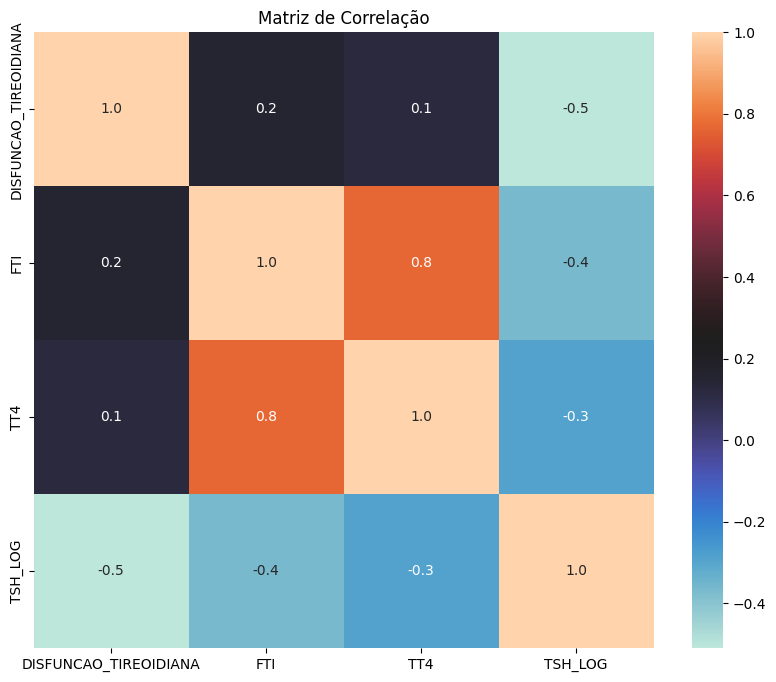

In [39]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df_reduzido.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='icefire', fmt='.1f', annot_kws={'size': 10})
plt.title('Matriz de Correlação')
plt.savefig(IMG_DIR / 'MATRIZ_DE_CORRELAÇÃO.png', dpi=300, transparent=True)
plt.show()


In [40]:
# PREPARAÇÃO PARA APRESENTAÇÃO DE GRÁFICOS

# Cores Padronizadas
COLOR_NEG = '#1F4E79'   
COLOR_POS = '#F46524'   

df_neg = df_reduzido[df_reduzido['DISFUNCAO_TIREOIDIANA'] == 0]
df_pos = df_reduzido[df_reduzido['DISFUNCAO_TIREOIDIANA'] == 1]


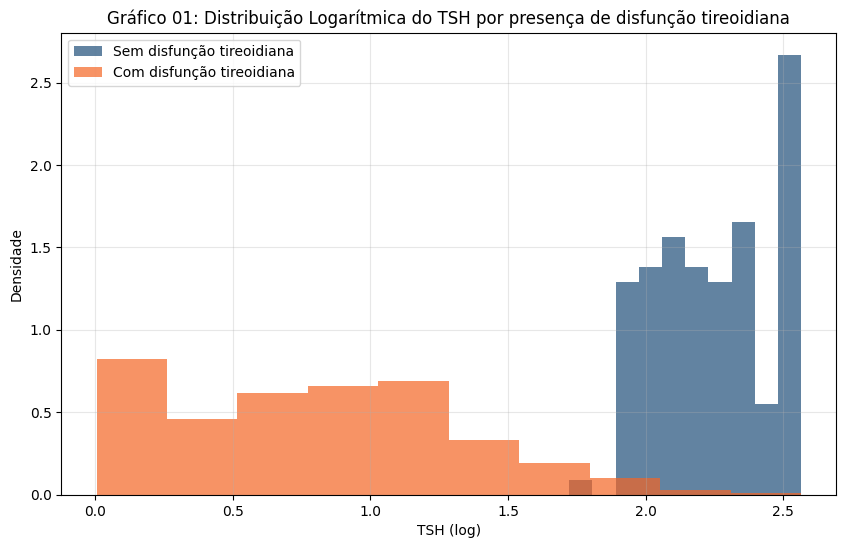

In [41]:
# GRÁFICO 01: DISTRIBUIÇÃO LOGARÍTMICA DO TSH POR Presença de disfunção tireoidiana

plt.figure(figsize=(10, 6)) 

plt.hist(df_neg['TSH_LOG'], bins=10, density=True, alpha=0.7,
         label='Sem disfunção tireoidiana', color=COLOR_NEG)

plt.hist(df_pos['TSH_LOG'], bins=10, density=True, alpha=0.7,
         label='Com disfunção tireoidiana', color=COLOR_POS)

plt.legend()
plt.xlabel('TSH (log)')
plt.ylabel('Densidade')
plt.title('Gráfico 01: Distribuição Logarítmica do TSH por presença de disfunção tireoidiana')
plt.grid(alpha=0.3)
plt.savefig(IMG_DIR / 'HIST_01_THS_DISF_TIREO.png', dpi=300)
plt.show()


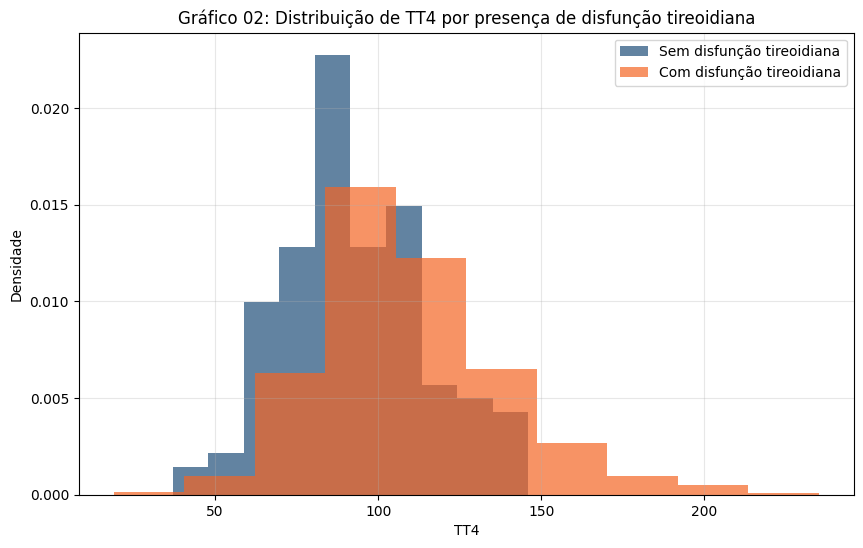

In [42]:
# GRÁFICO 02: DISTRIBUIÇÃO DE TT4 POR Presença de disfunção tireoidiana

plt.figure(figsize=(10, 6)) 

plt.hist(df_neg['TT4'], bins=10, density=True, alpha=0.7,
         label='Sem disfunção tireoidiana', color=COLOR_NEG)

plt.hist(df_pos['TT4'], bins=10, density=True, alpha=0.7,
         label='Com disfunção tireoidiana', color=COLOR_POS)

plt.legend()
plt.xlabel('TT4')
plt.ylabel('Densidade')
plt.title('Gráfico 02: Distribuição de TT4 por presença de disfunção tireoidiana')
plt.grid(alpha=0.3)

plt.savefig(IMG_DIR / 'HIST_02_TT4_DISF_TIREO.png', dpi=300)
plt.show()


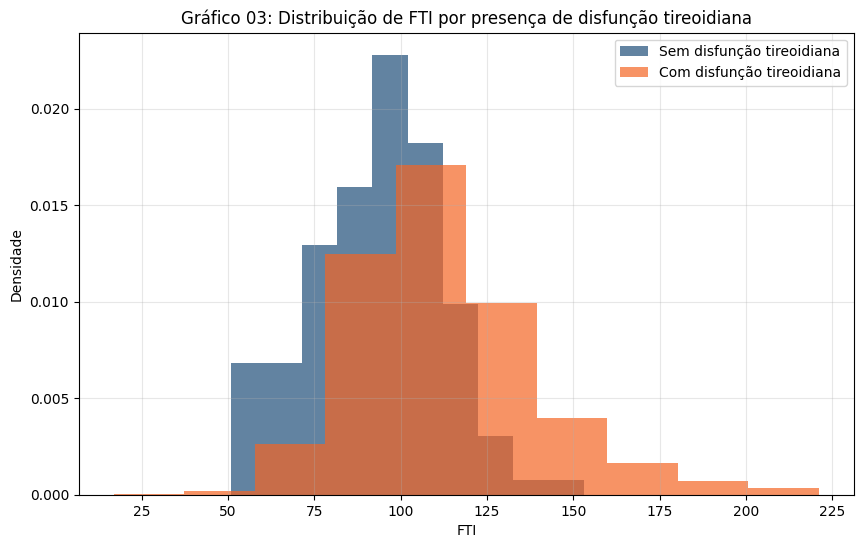

In [43]:
# GRÁFICO 03: DISTRIBUIÇÃO DE FTI POR Presença de disfunção tireoidiana

plt.figure(figsize=(10, 6)) 

plt.hist(df_neg['FTI'], bins=10, density=True, alpha=0.7,
         label='Sem disfunção tireoidiana', color=COLOR_NEG)

plt.hist(df_pos['FTI'], bins=10, density=True, alpha=0.7,
         label='Com disfunção tireoidiana', color=COLOR_POS)

plt.legend()
plt.xlabel('FTI')
plt.ylabel('Densidade')
plt.title('Gráfico 03: Distribuição de FTI por presença de disfunção tireoidiana')
plt.grid(alpha=0.3)

plt.savefig(IMG_DIR / 'HIST_03_FTI_DISF_TIREO.png', dpi=300)
plt.show()


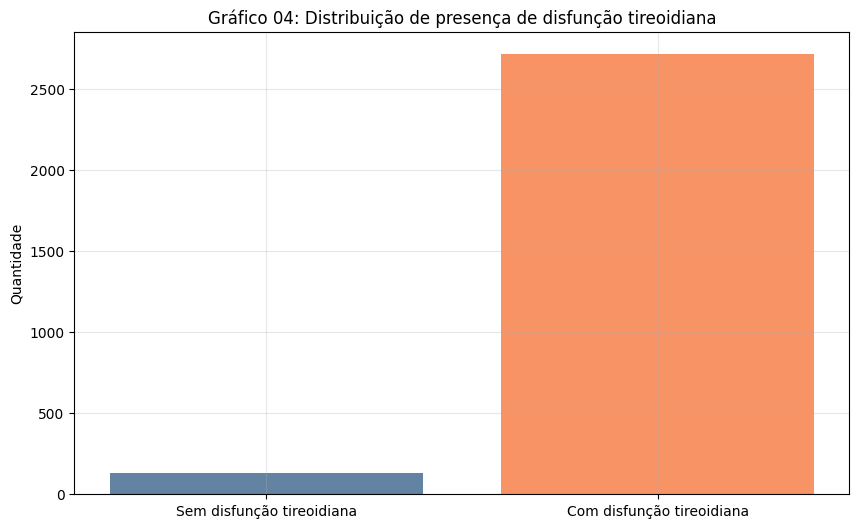

In [44]:
# GRÁFICO 04: DISTRIBUIÇÃO DE Presença de disfunção tireoidiana

fig, ax = plt.subplots(figsize=(10, 6))

counts = df['DISFUNCAO_TIREOIDIANA'].value_counts().sort_index()
bar_colors = [COLOR_NEG, COLOR_POS]
ax.bar(counts.index, counts.values, color=bar_colors, alpha=0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Sem disfunção tireoidiana', 'Com disfunção tireoidiana'])

ax.set_ylabel('Quantidade')
ax.set_title('Gráfico 04: Distribuição de presença de disfunção tireoidiana')

plt.grid(alpha=0.3)

plt.savefig(IMG_DIR / 'BAR_01_DISF_TIREO.png', dpi=300)
plt.show()


## Preparação de base teste e treino

In [45]:
# SEPARAÇÃO DE BASE TREINO E TESTE

X_train, X_test, y_train, y_test = train_test_split(
    df_reduzido.drop('DISFUNCAO_TIREOIDIANA', axis=1),
    df_reduzido['DISFUNCAO_TIREOIDIANA'],
    test_size=0.2,
    random_state=0
)

In [46]:
# PADRONIZAÇÃO DE DADOS

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Exploração inicial de modelos

In [47]:
# Cálculo do peso para XGBoost
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

scale_pos_weight = np.sqrt(n_neg / n_pos)

# modelos com tratamento de desbalanceamento
models = {
    'REGRESSÃO LOGÍSTICA': LogisticRegression(class_weight='balanced', random_state=0),
    'NAIVE BAYES': GaussianNB(),
    'SVM': SVC(class_weight='balanced', probability=True),
    'RANDOM FOREST': RandomForestClassifier(class_weight='balanced', random_state=0),
    'XGBOOST': xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=0)
}

kfold = model_selection.StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=0
)

print('='*30)
print('RESULTADOS DA EXPLORAÇÃO')
print('='*30, '\n')

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('model', model)
    ])

    scores = model_selection.cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=['precision', 'recall', 'f1', 'roc_auc'],
        cv=kfold,
        n_jobs=-1
    )

    precision = round(scores['test_precision'].mean(), 4)
    recall = round(scores['test_recall'].mean(), 4)
    f1 = round(scores['test_f1'].mean(), 4)
    roc_auc = round(scores['test_roc_auc'].mean(), 4)

    result = {
        'name': name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

    results.append(result)
    
    print(
        'NOME:', name,
        '\n\n-PRECISION:', precision,
        '\n-RECALL:', recall,
        '\n-F1-SCORE:', f1,
        '\n-ROC AUC:', roc_auc,
        '\n\n',
        '-'*30,
        '\n',
        sep=''
    )

RESULTADOS DA EXPLORAÇÃO

NOME:REGRESSÃO LOGÍSTICA

-PRECISION:0.9995
-RECALL:0.9644
-F1-SCORE:0.9816
-ROC AUC:0.9944

------------------------------

NOME:NAIVE BAYES

-PRECISION:0.9949
-RECALL:0.988
-F1-SCORE:0.9914
-ROC AUC:0.9942

------------------------------

NOME:SVM

-PRECISION:1.0
-RECALL:0.9718
-F1-SCORE:0.9857
-ROC AUC:0.994

------------------------------

NOME:RANDOM FOREST

-PRECISION:0.994
-RECALL:0.9889
-F1-SCORE:0.9914
-ROC AUC:0.9937

------------------------------

NOME:XGBOOST

-PRECISION:0.9972
-RECALL:0.9866
-F1-SCORE:0.9919
-ROC AUC:0.993

------------------------------



In [48]:
df_exploracao = pd.DataFrame(results)
df_exploracao.columns = df_exploracao.columns.str.upper()
df_exploracao = df_exploracao.round(3)
df_exploracao.head()

df_exploracao.to_csv(DATA_DIR / 'EXPLORACAO_MODELOS.csv')


In [49]:
# IDENTIFICACAO DE MODELOS MAIS PROMISSORES

for r in results:
    r['score'] = round(0.5 * r['roc_auc'] + 0.5 * r['f1'], 4)

results_sorted = sorted(
    results,
    key=itemgetter('score'),
    reverse=True
)

print('='*30)
print('RANKING FINAL')
print('='*30, '\n')
for r in results_sorted[:3]:
    print(
        'NOME:', r['name'],
        '\n\nPRECISION:', r['precision'],
        '\nRECALL:', r['recall'],
        '\nF1:', r['f1'],
        '\nROC_AUC:', r['roc_auc'],
        '\n\n',
        '-'*30,
        '\n',
        sep=''
    )

RANKING FINAL

NOME:NAIVE BAYES

PRECISION:0.9949
RECALL:0.988
F1:0.9914
ROC_AUC:0.9942

------------------------------

NOME:RANDOM FOREST

PRECISION:0.994
RECALL:0.9889
F1:0.9914
ROC_AUC:0.9937

------------------------------

NOME:XGBOOST

PRECISION:0.9972
RECALL:0.9866
F1:0.9919
ROC_AUC:0.993

------------------------------



## Aprofundamento de modelos promissores

In [50]:
# RANDOM FOREST

pipeline = Pipeline([
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=0
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_split': [4, 5, 6],
    'model__min_samples_leaf': [4, 5, 6],
    'model__max_features': ['sqrt', 'log2', None],
    'model__criterion': ['gini', 'entropy', 'log_loss']
}

grid_search_rf = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_train_best_rf = best_rf.predict(X_train)
y_pred_test_best_rf = best_rf.predict(X_test)

print('Melhores hiperparâmetros do Random Forest:')
print(grid_search_rf.best_params_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Melhores hiperparâmetros do Random Forest:
{'model__criterion': 'entropy', 'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 6, 'model__min_samples_split': 4, 'model__n_estimators': 100}


In [51]:
# XGBOOST

pipeline = Pipeline([
    ('model', xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=0
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1],
    'model__gamma': [0, 0.1, 0.3],
    'model__reg_alpha': [0, 0.1, 1],
}

grid_search_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)

best_xgboost = grid_search_xgb.best_estimator_
y_pred_train_best_xgboost = best_xgboost.predict(X_train)
y_pred_test_best_xgboost = best_xgboost.predict(X_test)

print('Melhores hiperparâmetros do XGBoost:')
print(grid_search_xgb.best_params_)


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Melhores hiperparâmetros do XGBoost:
{'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 100, 'model__reg_alpha': 0, 'model__subsample': 1}


In [52]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_train_best_nb = model_nb.predict(X_train)
y_pred_test_best_nb = model_nb.predict(X_test)

## Apresentação de resultados de modelos promissores

In [53]:
# APRESENTAÇÃO DE RESULTADOS DE TREINO

report_rf_train = classification_report(y_train, y_pred_train_best_rf, output_dict=True, target_names=['CLASSE 0', 'CLASSE 1'])
report_xgboost_train = classification_report(y_train, y_pred_train_best_xgboost, output_dict=True, target_names=['CLASSE 0', 'CLASSE 1'])
report_nb_train = classification_report(y_train, y_pred_train_best_nb, output_dict=True, target_names=['CLASSE 0', 'CLASSE 1'])

df_report_rf_train = pd.DataFrame(report_rf_train)
df_report_xgboost_train = pd.DataFrame(report_xgboost_train)
df_report_nb_train = pd.DataFrame(report_nb_train)

# PADRONIZAÇÃO DE NOMES DE COLUNAS, ARREDONDAMENTO DE VALORES E APRESENTAÇÃO DE RESULTADOS
df_report_rf_train.columns = df_report_rf_train.columns.str.upper()
df_report_xgboost_train.columns = df_report_xgboost_train.columns.str.upper()
df_report_nb_train.columns = df_report_nb_train.columns.str.upper()

df_report_rf_train = df_report_rf_train.round(3)
df_report_xgboost_train = df_report_xgboost_train.round(3)
df_report_nb_train = df_report_nb_train.round(3)

print("MÉTRICAS RANDOM FOREST")
print(df_report_rf_train)
print("\nMÉTRICAS XGBOOST")
print(df_report_xgboost_train)
print("\nMÉTRICAS NAIVE BAYES")
print(df_report_nb_train)

df_report_rf_train.to_csv(DATA_DIR / 'REPORT_RF_TRAIN.csv')
df_report_xgboost_train.to_csv(DATA_DIR / 'REPORT_XGBOOST_TRAIN.csv')
df_report_nb_train.to_csv(DATA_DIR / 'REPORT_NB_TRAIN.csv')


MÉTRICAS RANDOM FOREST
           CLASSE 0  CLASSE 1  ACCURACY  MACRO AVG  WEIGHTED AVG
precision     0.790     1.000     0.987      0.895         0.990
recall        1.000     0.986     0.987      0.993         0.987
f1-score      0.883     0.993     0.987      0.938         0.988
support     113.000  2163.000     0.987   2276.000      2276.000

MÉTRICAS XGBOOST
           CLASSE 0  CLASSE 1  ACCURACY  MACRO AVG  WEIGHTED AVG
precision     0.789     1.000     0.986      0.894         0.989
recall        0.991     0.986     0.986      0.989         0.986
f1-score      0.878     0.993     0.986      0.936         0.987
support     113.000  2163.000     0.986   2276.000      2276.000

MÉTRICAS NAIVE BAYES
           CLASSE 0  CLASSE 1  ACCURACY  MACRO AVG  WEIGHTED AVG
precision     0.798     0.995     0.984      0.897         0.986
recall        0.912     0.988     0.984      0.950         0.984
f1-score      0.851     0.992     0.984      0.921         0.985
support     113.000  2163.0

In [54]:
# APRESENTAÇÃO DE RESULTADOS DE TESTE

report_rf = classification_report(y_test, y_pred_test_best_rf, output_dict=True, target_names=['CLASSE 0', 'CLASSE 1'])
report_xgboost = classification_report(y_test, y_pred_test_best_xgboost, output_dict=True, target_names=['CLASSE 0', 'CLASSE 1'])
report_nb = classification_report(y_test, y_pred_test_best_nb, output_dict=True, target_names=['CLASSE 0', 'CLASSE 1'])

df_report_rf_test = pd.DataFrame(report_rf)
df_report_xgboost_test = pd.DataFrame(report_xgboost)
df_report_nb_test = pd.DataFrame(report_nb)

# PADRONIZAÇÃO DE NOMES DE COLUNAS, ARREDONDAMENTO DE VALORES E APRESENTAÇÃO DE RESULTADOS
df_report_rf_test.columns = df_report_rf_test.columns.str.upper()
df_report_xgboost_test.columns = df_report_xgboost_test.columns.str.upper()
df_report_nb_test.columns = df_report_nb_test.columns.str.upper()

df_report_rf_test = df_report_rf_test.round(3)
df_report_xgboost_test = df_report_xgboost_test.round(3)
df_report_nb_test = df_report_nb_test.round(3)

print("MÉTRICAS RANDOM FOREST")
print(df_report_rf_test)
print("\nMÉTRICAS XGBOOST")
print(df_report_xgboost_test)
print("\nMÉTRICAS NAIVE BAYES")
print(df_report_nb_test)

df_report_rf_test.to_csv(DATA_DIR / 'REPORT_RF_TEST.csv')
df_report_xgboost_test.to_csv(DATA_DIR / 'REPORT_XGBOOST_TEST.csv')
df_report_nb_test.to_csv(DATA_DIR / 'REPORT_NB_TEST.csv')


MÉTRICAS RANDOM FOREST
           CLASSE 0  CLASSE 1  ACCURACY  MACRO AVG  WEIGHTED AVG
precision     0.667     1.000     0.986      0.833         0.991
recall        1.000     0.986     0.986      0.993         0.986
f1-score      0.800     0.993     0.986      0.896         0.987
support      16.000   554.000     0.986    570.000       570.000

MÉTRICAS XGBOOST
           CLASSE 0  CLASSE 1  ACCURACY  MACRO AVG  WEIGHTED AVG
precision     0.762     1.000     0.991      0.881         0.993
recall        1.000     0.991     0.991      0.995         0.991
f1-score      0.865     0.995     0.991      0.930         0.992
support      16.000   554.000     0.991    570.000       570.000

MÉTRICAS NAIVE BAYES
           CLASSE 0  CLASSE 1  ACCURACY  MACRO AVG  WEIGHTED AVG
precision     0.714     0.998     0.988      0.856         0.990
recall        0.938     0.989     0.988      0.963         0.988
f1-score      0.811     0.994     0.988      0.902         0.989
support      16.000   554.0

**MODELO MAIS ADEQUADO:** XGBOOST.

## Detalhamento dos resultados do melhor modelo (XGBOOST)

In [55]:
# DEFINICAO DE MELHOR MODELO 

best_model = best_xgboost
y_pred = y_pred_test_best_xgboost
y_prob = best_model.predict_proba(X_test)[:,1]

# FEATURE IMPORTANCE DO MELHOR MODELO (XGBOOST)
feature_names = df_reduzido.drop('DISFUNCAO_TIREOIDIANA', axis=1).columns
importances = best_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'FEATURE': feature_names,
    'IMPORTANCE': importances
}).sort_values('IMPORTANCE', ascending=False).reset_index(drop=True)

feature_importance_df.to_csv(DATA_DIR / 'FEATURE_IMPORTANCE_XGBOOST.csv', index=False)


In [56]:
# EXPORTAÇÃO DO CLASSIFICATION REPORT

df_report_best_model = df_report_xgboost_test
df_report_best_model.to_csv(DATA_DIR / 'BEST_MODEL_REPORT.csv')


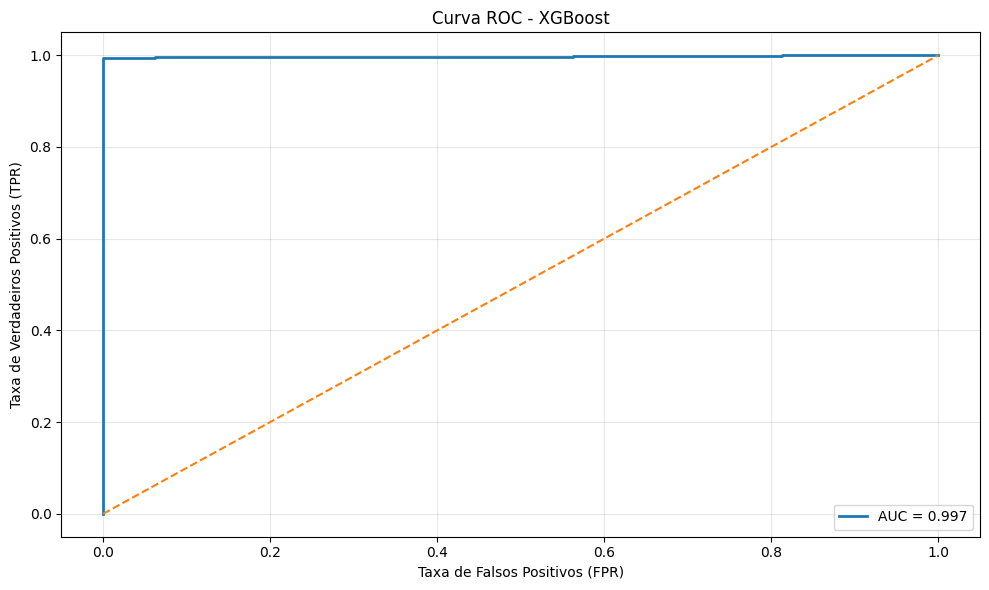

In [57]:
# CURVA ROC DO MELHOR MODELO (XGBOOST)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(10, 6))

plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - XGBoost')

plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.savefig(IMG_DIR / 'CURVA_ROC_XGBOOST.png', dpi=300, transparent=True)
plt.tight_layout()
plt.show()


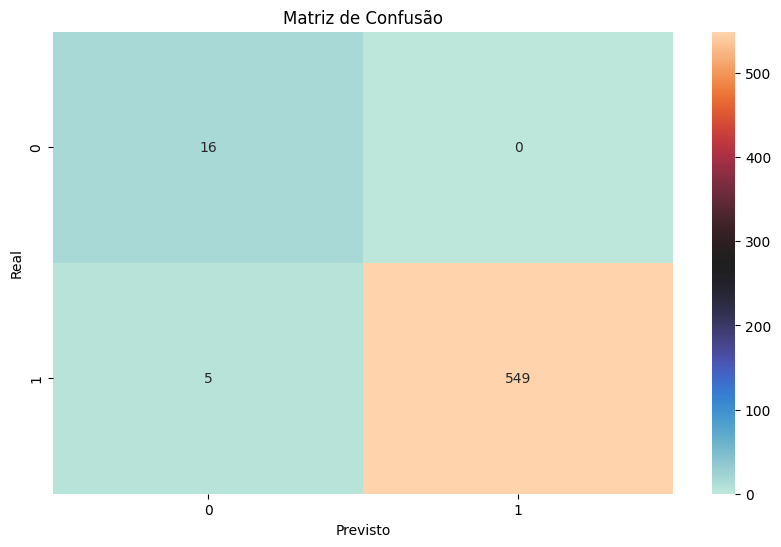

In [58]:
# MATRIZ DE CONFUSÃO DO MELHOR MODELO (XGBOOST)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='icefire')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig(IMG_DIR / 'MATRIZ_DE_CONFUSAO_XGBOOST.png', dpi=300, transparent=True)
plt.show()
